<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%A0%D0%B5%D0%BA%D1%83%D1%80%D1%80%D0%B5%D0%BD%D1%82%D0%BD%D1%8B%D0%B5_%D0%B8_%D0%BE%D0%B4%D0%BD%D0%BE%D0%BC%D0%B5%D1%80%D0%BD%D1%8B%D0%B5_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_%7C_%D0%94%D0%97_Ultra_Pro_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Задание состоит из нескольких пунктов, которые необходимо выполнить для получения высокой оценки.

1. Скачайте корпус текстов двадцати русских писателей.
2. Разбейте каждый текст на обучающую и тестовую выборки.
3. Разработайте и обучите нейронную сеть, которая будет определять авторство фрагментов текста (на основе тестовой выборки).
Добейтесь точности нейросети 50% и выше
4. Скачайте своё сочинение или чьё-нибудь другое из архива.
5. Создайте из него проверочную выборку.
6. Предложите нейронной сети предсказать автора сочинения (по проверочной выборке).
7. Объявите себя великим писателем, например, Гончаровым.


Ссылка на архив: https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip

В работе рекомендуется пользоваться материалами из ноутбука практического занятия «Рекуррентные и одномерные свёрточные нейронные сети». Допускается выбрать лучший вариант нейронной сети и адаптировать её структуру, параметры обучения и формирования датасетов под свои нужды.

In [ ]:
# ваше решение

In [1]:
# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Рисование схемы модели
from tensorflow.keras.utils import plot_model

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Вывод объектов в ячейке colab
from IPython.display import display

%matplotlib inline

In [2]:
# Скачаем архив
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip', None, quiet=True)

'20writers.zip'

In [3]:
# Распакуем архив
!unzip -o 20writers.zip
!mkdir 20writers
!mv *.txt ./20writers/

Archive:  20writers.zip
  inflating: Грибоедов.txt  
  inflating: Достоевский.txt  
  inflating: Каверин.txt      
  inflating: Катаев.txt        
  inflating: Куприн.txt        
  inflating: Лермонтов.txt  
  inflating: Лесков.txt        
  inflating: Носов.txt          
  inflating: Пастернак.txt  
  inflating: Пушкин.txt        
  inflating: Толстой.txt      
  inflating: Тургенев.txt    
  inflating: Чехов.txt          
  inflating: Шолохов.txt      
  inflating: Беляев.txt        
  inflating: Булгаков.txt    
  inflating: Васильев.txt    
  inflating: Гоголь.txt        
  inflating: Гончаров.txt    
  inflating: Горький.txt      


In [4]:
FILE_DIR  = './20writers'

In [5]:
# Подготовим пустые списки

CLASS_LIST = []  # Список классов
text_train = []  # Список для оучающей выборки
text_test = []   # Список для тестовой выборки

# Зададим коэффициент разделения текста на обучающую и текстовую выборки
split_coef = 0.8

# Получим списки файлов в папке
file_list = os.listdir(FILE_DIR)

for file_name in file_list:
    m = file_name.split('.') # Разделим имя файла и расширение
    class_name = m[0]        # Из имени файла получим название класса
    ext = m[1]               # Выделим расширение файла

    if ext=='txt':                                         # Если расширение txt то берем файл в работу
        if class_name not in CLASS_LIST:                   # Проверим, есть уже такой класс в списке
            print(f'Добавление класса "{class_name}"')     # Выведем имя нового класса
            CLASS_LIST.append(class_name)                  # Добавим новый класс в списоккласса "{class_name}"')

        cls = CLASS_LIST.index(class_name)                                        # Получим индекс (номер) нового класса
        print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}"')      # Сообщим о появлении нового класса

        with open(f'{FILE_DIR}/{file_name}', 'r') as f: # Откроем файл на чтение
            text = f.read()                                                       # Загрузка содержимого файла в строку
            text = text.replace('\n', ' ').split(' ')                             # Уберем символы перевода строк, получим список слов
            text_len=len(text)                                                    # Найдем количество прочитанных слов
            text_train.append(' '.join(text[:int(text_len*split_coef)]))          # Выделим часть файла в обучающую выборку
            text_test.append(' '.join(text[int(text_len*split_coef):]))           # Выделим часть файла в тестовую выборку

Добавление класса "Булгаков"
Добавление файла "Булгаков.txt" в класс "Булгаков"
Добавление класса "Гоголь"
Добавление файла "Гоголь.txt" в класс "Гоголь"
Добавление класса "Толстой"
Добавление файла "Толстой.txt" в класс "Толстой"
Добавление класса "Каверин"
Добавление файла "Каверин.txt" в класс "Каверин"
Добавление класса "Шолохов"
Добавление файла "Шолохов.txt" в класс "Шолохов"
Добавление класса "Куприн"
Добавление файла "Куприн.txt" в класс "Куприн"
Добавление класса "Тургенев"
Добавление файла "Тургенев.txt" в класс "Тургенев"
Добавление класса "Катаев"
Добавление файла "Катаев.txt" в класс "Катаев"
Добавление класса "Пастернак"
Добавление файла "Пастернак.txt" в класс "Пастернак"
Добавление класса "Горький"
Добавление файла "Горький.txt" в класс "Горький"
Добавление класса "Беляев"
Добавление файла "Беляев.txt" в класс "Беляев"
Добавление класса "Лесков"
Добавление файла "Лесков.txt" в класс "Лесков"
Добавление класса "Носов"
Добавление файла "Носов.txt" в класс "Носов"
Добавлен

In [6]:
# Найдем получившееся количество классов
CLASS_COUNT = len(CLASS_LIST)
# Выведем число получившихся классов
print(CLASS_COUNT)

20


In [7]:
# Проверим загрузки: выведем начальные отрывки из каждого класса

for cls in range(CLASS_COUNT):             # Запустим цикл по числу классов
    print(f'Класс: {CLASS_LIST[cls]}')     # Выведем имя класса
    print(f'  train: {text_train[cls][:200]}')   # Выведем фрагмент обучающей выборки
    print(f'  test : {text_test[cls][:200]}')    # Выведем фрагмент тестовой выборки
    print()

Класс: Булгаков
  train: ﻿Черновики романа. Тетрадь 1 1928 - 1929 гг. РАЗГОВОР ПО ДУШАМ - Значит, гражданин Поротый, две тысячи рублей вы уплатили гражданину Иванову за дом в Серпухове? - Да, так. Так точно, - уплатил я. Толь
  test : Ты помер, скажем, к примеру, какая разница. Какая разница, ответь мне, гражданин?   - Не обижайте!   - Не обижаю, а внушить хочу. Помер великий человек, поэтому помолчи. Помолчи минутку, сообрази в го

Класс: Гоголь
  train: ﻿Гоголь Николай Васильевич. Мертвые души. Поэма.  We may guess that it was a pretty apt expression, since long after the man had become lost to view Chichikov was still laughing in his britchka. And, 
  test : безделицу и рассматривает ее. Тогда он принадлежит к другому миру и ничего не разделяет человеческого. Видит без мыслей; чувствует не чувствуя; странно живет. Прежде всего внимание его впилось в темно

Класс: Толстой
  train: ﻿ ГЛАВА I. ПОЕЗДКА НА ДОЛГИХ.  Снова поданы два экипажа к крыльцу Петровского дома; один – карета, в кот

In [8]:
#ваше решение
VOCAB_SIZE = 20000                        # Объем словаря для токенизатора
WIN_SIZE   = 1000                         # Длина отрезка текста (окна) в словах
WIN_HOP    = 100                          # Шаг окна разбиения текста на векторы
tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                          lower=True, split=' ', oov_token='неизвестное_слово', char_level=False)

# Построение частотного словаря по обучающим текстам
tokenizer.fit_on_texts(text_train)
# Построение словаря в виде пар слово - индекс
items = list(tokenizer.word_index.items())
# Преобразование обучающих и проверочных текстов в последовательность индексов согласно частотному словарю
seq_train = tokenizer.texts_to_sequences(text_train)
seq_test = tokenizer.texts_to_sequences(text_test)

In [9]:
# Функция вывода статистики по текстам
def print_text_stats(title, texts, sequences, class_labels=CLASS_LIST):
    # Суммарное количество символов и слов в тексте
    chars = 0
    words = 0

    print(f'Статистика по {title} текстам:')

    # Вывод итогов по всем классам данного набора текстов и их последовательностей индексов
    for cls in range(len(class_labels)):
        print('{:<15} {:9} символов,{:8} слов'.format(class_labels[cls],
                                                      len(texts[cls]),
                                                      len(sequences[cls])))
        chars += len(texts[cls])
        words += len(sequences[cls])

    print('----')
    print('{:<15} {:9} символов,{:8} слов\n'.format('В сумме', chars, words))

# Вывод итогов по текстам
print_text_stats('обучающим', text_train, seq_train)
print_text_stats('тестовым', text_test, seq_test)

Статистика по обучающим текстам:
Булгаков          1616636 символов,  240825 слов
Гоголь            1573975 символов,  243382 слов
Толстой           2668527 символов,  415441 слов
Каверин           1612560 символов,  245670 слов
Шолохов           2727901 символов,  402138 слов
Куприн            1864010 символов,  283004 слов
Тургенев          1583819 символов,  245677 слов
Катаев            2045572 символов,  301965 слов
Пастернак         2432606 символов,  360889 слов
Горький           2013335 символов,  326593 слов
Беляев            1804564 символов,  269640 слов
Лесков            1705301 символов,  269869 слов
Носов             1943249 символов,  300382 слов
Достоевский       4153922 символов,  652424 слов
Пушкин            2717821 символов,  413981 слов
Гончаров          2460584 символов,  390199 слов
Лермонтов         1581907 символов,  248390 слов
Грибоедов          768762 символов,  122171 слов
Васильев          2354798 символов,  355641 слов
Чехов             5303458 символов, 

In [10]:
# Функция разбиения последовательности на отрезки скользящим окном
# На входе - последовательность индексов, размер окна, шаг окна
def split_sequence(sequence, win_size, hop):
    # Последовательность разбивается на части до последнего полного окна
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]


# Функция формирования выборок из последовательностей индексов
# формирует выборку отрезков и соответствующих им меток классов в виде one hot encoding
def vectorize_sequence(seq_list, win_size, hop):
    # В списке последовательности следуют в порядке их классов
    # Всего последовательностей в списке ровно столько, сколько классов
    class_count = len(seq_list)

    # Списки для исходных векторов и категориальных меток класса
    x, y = [], []

    # Для каждого класса:
    for cls in range(class_count):
        # Разбиение последовательности класса cls на отрезки
        vectors = split_sequence(seq_list[cls], win_size, hop)
        # Добавление отрезков в выборку
        x += vectors
        # Для всех отрезков класса cls добавление меток класса в виде OHE
        y += [utils.to_categorical(cls, class_count)] * len(vectors)

    # Возврат результатов как numpy-массивов
    return np.array(x), np.array(y)

In [11]:
 # Формирование обучающей выборки
x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
# Формирование тестовой выборки
x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)

# Проверка формы сформированных данных
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(69031, 1000) (69031, 20)
(17273, 1000) (17273, 20)


In [12]:
# Функция компиляции и обучения модели нейронной сети
def compile_train_model(model,
                        x_train,
                        y_train,
                        x_val,
                        y_val,
                        optimizer='adam',
                        epochs=50,
                        batch_size=128,
                        figsize=(20, 5)):

    # Компиляция модели
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Вывод сводки
    model.summary()

    # Вывод схемы модели
    display(plot_model(model, dpi=60, show_shapes=True))

    # Обучение модели с заданными параметрами
    history = model.fit(x_train,
                        y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_val, y_val))

    # Вывод графиков точности и ошибки
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'],
               label='Доля верных ответов на обучающем наборе')
    ax1.plot(history.history['val_accuracy'],
               label='Доля верных ответов на проверочном наборе')
    ax1.xaxis.get_major_locator().set_params(integer=True)
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('Доля верных ответов')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающем наборе')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочном наборе')
    ax2.xaxis.get_major_locator().set_params(integer=True)
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()


# Функция вывода результатов оценки модели на заданных данных
def eval_model(model, x, y_true,
               class_labels=[],
               cm_round=3,
               title='',
               figsize=(10, 10)):
    # Вычисление предсказания сети
    y_pred = model.predict(x)
    # Построение матрицы ошибок
    cm = confusion_matrix(np.argmax(y_true, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')
    # Округление значений матрицы ошибок
    cm = np.around(cm, cm_round)

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f'Нейросеть {title}: матрица ошибок нормализованная', fontsize=18)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()  # Стирание ненужной цветовой шкалы
    plt.xlabel('Предсказанные классы', fontsize=16)
    plt.ylabel('Верные классы', fontsize=16)
    fig.autofmt_xdate(rotation=45)          # Наклон меток горизонтальной оси при необходимости
    plt.show()

    print('-'*100)
    print(f'Нейросеть: {title}')

    # Для каждого класса:
    for cls in range(len(class_labels)):
        # Определяется индекс класса с максимальным значением предсказания (уверенности)
        cls_pred = np.argmax(cm[cls])
        # Формируется сообщение о верности или неверности предсказания
        msg = 'ВЕРНО :-)' if cls_pred == cls else 'НЕВЕРНО :-('
        # Выводится текстовая информация о предсказанном классе и значении уверенности
        print('Класс: {:<20} {:3.0f}% сеть отнесла к классу {:<20} - {}'.format(class_labels[cls],
                                                                               100. * cm[cls, cls_pred],
                                                                               class_labels[cls_pred],
                                                                               msg))

    # Средняя точность распознавания определяется как среднее диагональных элементов матрицы ошибок
    print('\nСредняя точность распознавания: {:3.0f}%'.format(100. * cm.diagonal().mean()))


# Совместная функция обучения и оценки модели нейронной сети
def compile_train_eval_model(model,
                             x_train,
                             y_train,
                             x_test,
                             y_test,
                             class_labels=CLASS_LIST,
                             title='',
                             optimizer='adam',
                             epochs=50,
                             batch_size=128,
                             graph_size=(20, 5),
                             cm_size=(10, 10)):

    # Компиляция и обучение модели на заданных параметрах
    # В качестве проверочных используются тестовые данные
    compile_train_model(model,
                        x_train, y_train,
                        x_test, y_test,
                        optimizer=optimizer,
                        epochs=epochs,
                        batch_size=batch_size,
                        figsize=graph_size)

    # Вывод результатов оценки работы модели на тестовых данных
    eval_model(model, x_test, y_test,
               class_labels=class_labels,
               title=title,
               figsize=cm_size)

In [13]:
model = Sequential()
model.add(Embedding(VOCAB_SIZE, 50, input_length=WIN_SIZE))
model.add(SpatialDropout1D(0.4))
model.add(BatchNormalization())
# Два двунаправленных рекуррентных слоя LSTM
model.add(Bidirectional(LSTM(8, return_sequences=True)))
model.add(Bidirectional(LSTM(8, return_sequences=True)))
model.add(Dropout(0.3))
model.add(BatchNormalization())
# Два рекуррентных слоя GRU
model.add(GRU(16, return_sequences=True, reset_after=True))
model.add(GRU(16, reset_after=True))
model.add(Dropout(0.3))
model.add(BatchNormalization())
# Дополнительный полносвязный слой
model.add(Dense(200, activation='relu'))
model.add(Dropout(0.3))
model.add(BatchNormalization())
model.add(Dense(CLASS_COUNT, activation='softmax'))
model.build()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 1000, 50)            │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1000, 50)            │             200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 1000, 16)            │           3,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 1000, 16)            │           1,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 1000, 16)            │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 1000, 16)            │           1,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 16)                  │           1,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 200)                 │           3,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 200)                 │             800 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │           4,020 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,017,188 (3.88 MB)

 Trainable params: 1,016,624 (3.88 MB)

 Non-trainable params: 564 (2.20 KB)

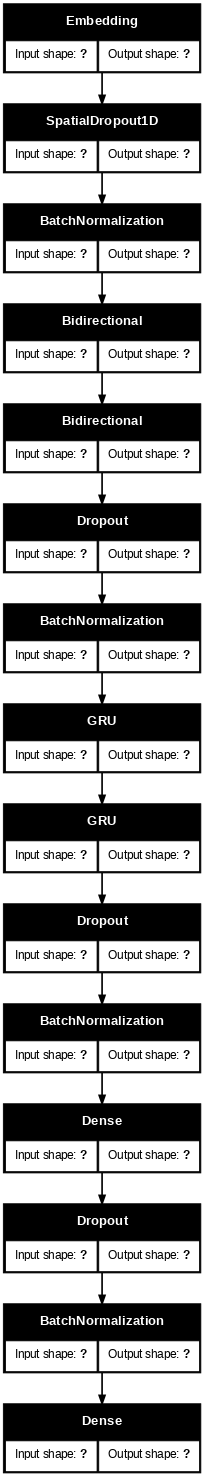

Epoch 1/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 46s 269ms/step - accuracy: 0.0982 - loss: 3.0493 - val_accuracy: 0.1035 - val_loss: 2.9524
Epoch 2/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 36s 266ms/step - accuracy: 0.1521 - loss: 2.7155 - val_accuracy: 0.1734 - val_loss: 2.5422
Epoch 3/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 38s 282ms/step - accuracy: 0.2139 - loss: 2.4332 - val_accuracy: 0.2239 - val_loss: 2.3376
Epoch 4/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 39s 287ms/step - accuracy: 0.2621 - loss: 2.3585 - val_accuracy: 0.1902 - val_loss: 2.9941
Epoch 5/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 38s 267ms/step - accuracy: 0.4212 - loss: 1.7393 - val_accuracy: 0.5562 - val_loss: 1.3338
Epoch 6/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 41s 270ms/step - accuracy: 0.5990 - loss: 1.1759 - val_accuracy: 0.1003 - val_loss: 5.2970
Epoch 7/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 36s 270ms/step - accuracy: 0.4987 - loss: 1.5339 - val_accuracy: 0.5227 - val_loss: 1.4558
Epoch 8/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 43s 287ms/step - accuracy: 0.7605 -

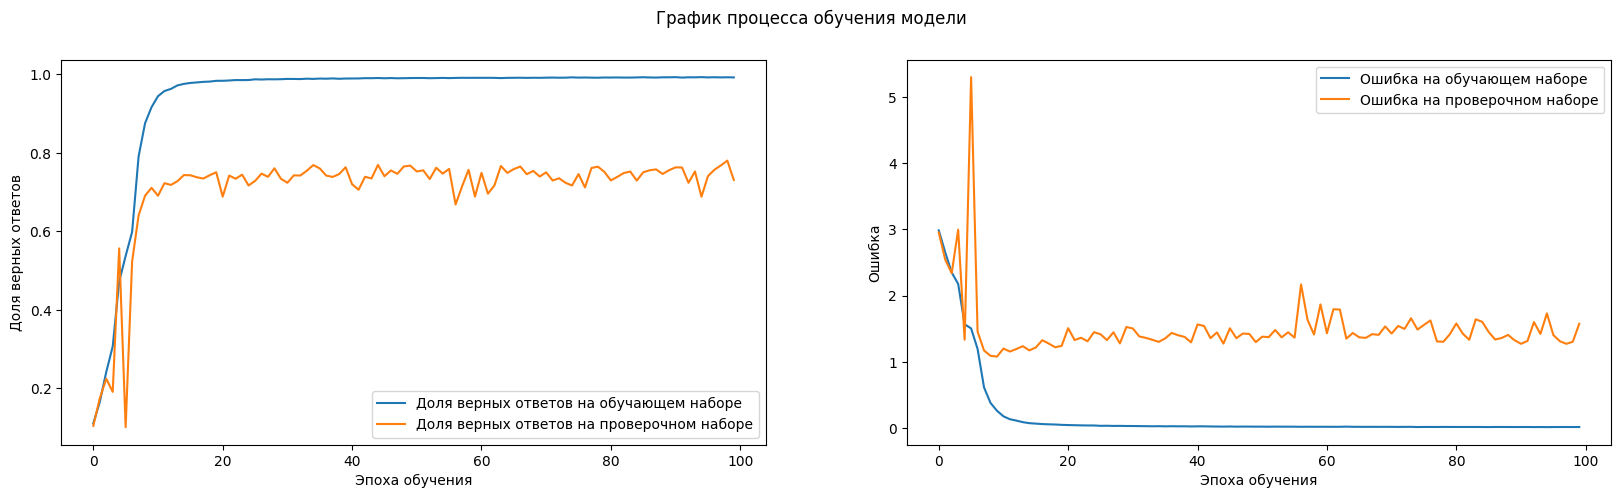

540/540 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step


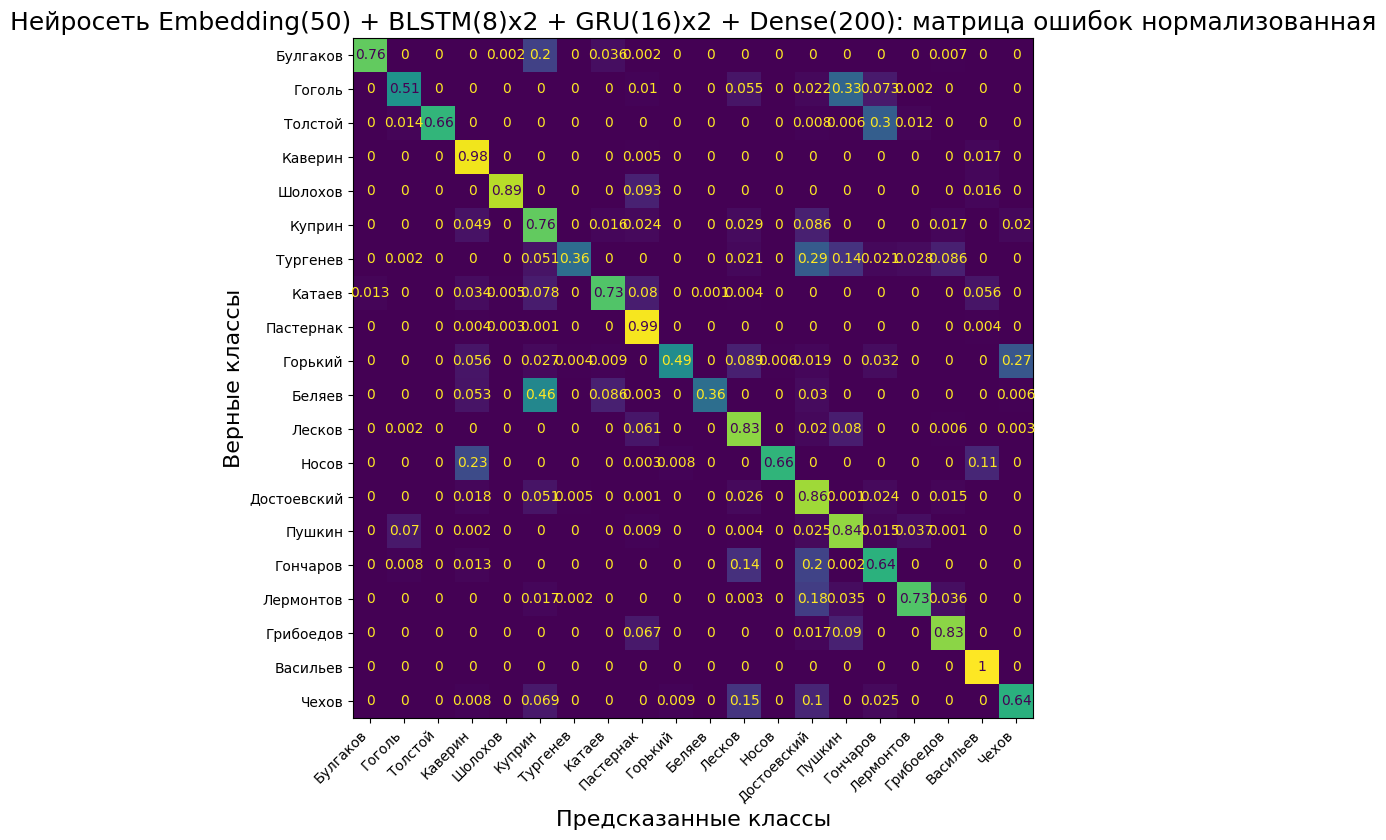

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200)
Класс: Булгаков              76% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Гоголь                51% сеть отнесла к классу Гоголь               - ВЕРНО :-)
Класс: Толстой               66% сеть отнесла к классу Толстой              - ВЕРНО :-)
Класс: Каверин               98% сеть отнесла к классу Каверин              - ВЕРНО :-)
Класс: Шолохов               89% сеть отнесла к классу Шолохов              - ВЕРНО :-)
Класс: Куприн                76% сеть отнесла к классу Куприн               - ВЕРНО :-)
Класс: Тургенев              36% сеть отнесла к классу Тургенев             - ВЕРНО :-)
Класс: Катаев                73% сеть отнесла к классу Катаев               - ВЕРНО :-)
Класс: Пастернак             99% сеть отнесла к классу Пастернак            - ВЕРНО :-)
Класс: Горький               49% сеть отнесл

In [15]:
compile_train_eval_model(model,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200)')